# 📰 Exploratory Data Analysis — News Datasets

This notebook explores the **LIAR** and **ISOT Fake News** datasets to understand:
- Class distribution (real vs. fake)
- Text length patterns
- Most common words and phrases
- Dataset-specific metadata (speakers, subjects, etc.)

---

**Datasets:**
| Dataset | Size | Labels | Source |
|---------|------|--------|--------|
| LIAR | ~12.8K | 6-class → binary | PolitiFact via HuggingFace |
| ISOT | ~44K | binary | Kaggle (manual download) |

## Setup

In [1]:
import sys
import os
sys.path.insert(0, os.path.abspath('..'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from collections import Counter

from src.data.load_data import load_liar, load_isot
from src.utils import apply_plot_style, save_figure, PALETTE_BINARY, LABEL_COLORS

# Apply consistent styling
apply_plot_style()

# Download NLTK data
import nltk
nltk.download('stopwords', quiet=True)
from nltk.corpus import stopwords
STOP_WORDS = set(stopwords.words('english'))

print('Setup complete ✓')

ModuleNotFoundError: No module named 'src'

---
## 1. LIAR Dataset

### 1.1 Load Data

In [ ]:
df_liar = load_liar()
print(f'Shape: {df_liar.shape}')
print(f'Columns: {list(df_liar.columns)}')
df_liar.head()

Shape: (12836, 9)
Columns: ['text', 'label', 'label_binary', 'speaker', 'party', 'subject', 'context', 'source', 'split']


,text,label,label_binary,speaker,party,subject,context,source,split
0,Says the Annies List political group supports ...,false,1,dwayne-bohac,republican,abortion,a mailer,liar,train
1,When did the decline of coal start? It started...,half-true,0,scott-surovell,democrat,"energy,history,job-accomplishments",a floor speech.,liar,train
2,"Hillary Clinton agrees with John McCain ""by vo...",mostly-true,0,barack-obama,democrat,foreign-policy,Denver,liar,train
3,Health care reform legislation is likely to ma...,false,1,blog-posting,none,health-care,a news release,liar,train
4,The economic turnaround started at the end of ...,half-true,0,charlie-crist,democrat,"economy,jobs",an interview on CNN,liar,train


In [ ]:
# Quick overview
print('--- Data Types ---')
print(df_liar.dtypes)
print(f'\n--- Missing Values ---')
print(df_liar.isnull().sum())
print(f'\n--- Unique Labels ---')
print(df_liar['label'].value_counts())

--- Data Types ---
text              str
label             str
label_binary    int64
speaker           str
party             str
subject           str
context           str
source            str
split             str
dtype: object

--- Missing Values ---
text              0
label             0
label_binary      0
speaker           0
party             0
subject           0
context         129
source            0
split             0
dtype: int64

--- Unique Labels ---
label
half-true      2638
false          2511
mostly-true    2466
barely-true    2108
true           2063
pants-fire     1050
Name: count, dtype: int64


### 1.2 Label Distribution

Figure saved: C:\Users\dawoo\OneDrive\Desktop\HASEEB\fake project\reports\figures\liar_label_distribution.png


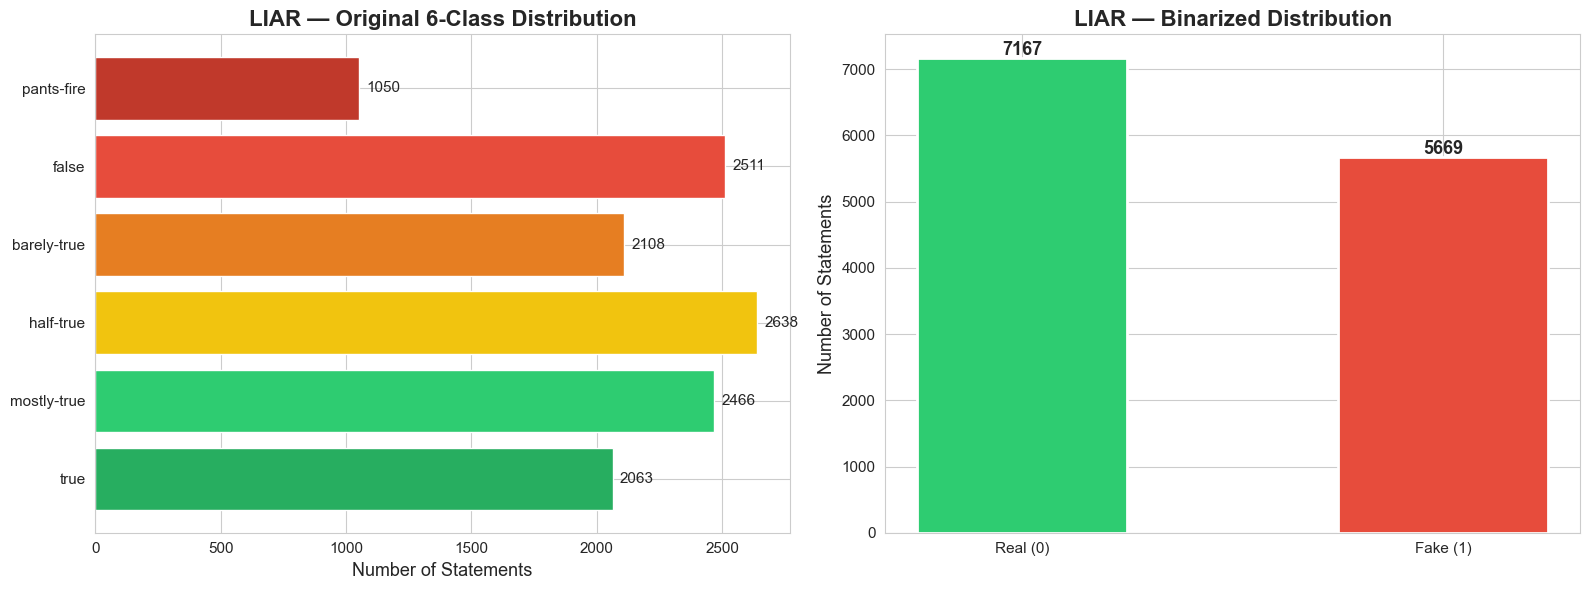

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Original 6-class distribution
label_order = ['true', 'mostly-true', 'half-true', 'barely-true', 'false', 'pants-fire']
colors_6 = ['#27ae60', '#2ecc71', '#f1c40f', '#e67e22', '#e74c3c', '#c0392b']

label_counts = df_liar['label'].value_counts().reindex(label_order)
axes[0].barh(label_counts.index, label_counts.values, color=colors_6)
axes[0].set_xlabel('Number of Statements')
axes[0].set_title('LIAR — Original 6-Class Distribution', fontweight='bold')
for i, v in enumerate(label_counts.values):
    axes[0].text(v + 30, i, str(v), va='center', fontsize=11)

# Binary distribution
binary_counts = df_liar['label_binary'].value_counts().sort_index()
binary_labels = ['Real (0)', 'Fake (1)']
axes[1].bar(binary_labels, binary_counts.values, color=PALETTE_BINARY, width=0.5, edgecolor='white', linewidth=2)
axes[1].set_ylabel('Number of Statements')
axes[1].set_title('LIAR — Binarized Distribution', fontweight='bold')
for i, v in enumerate(binary_counts.values):
    axes[1].text(i, v + 50, str(v), ha='center', fontsize=13, fontweight='bold')

plt.tight_layout()
save_figure(fig, 'liar_label_distribution.png')
plt.show()

### 1.3 Text Length Distribution

Figure saved: C:\Users\dawoo\OneDrive\Desktop\HASEEB\fake project\reports\figures\liar_text_length.png


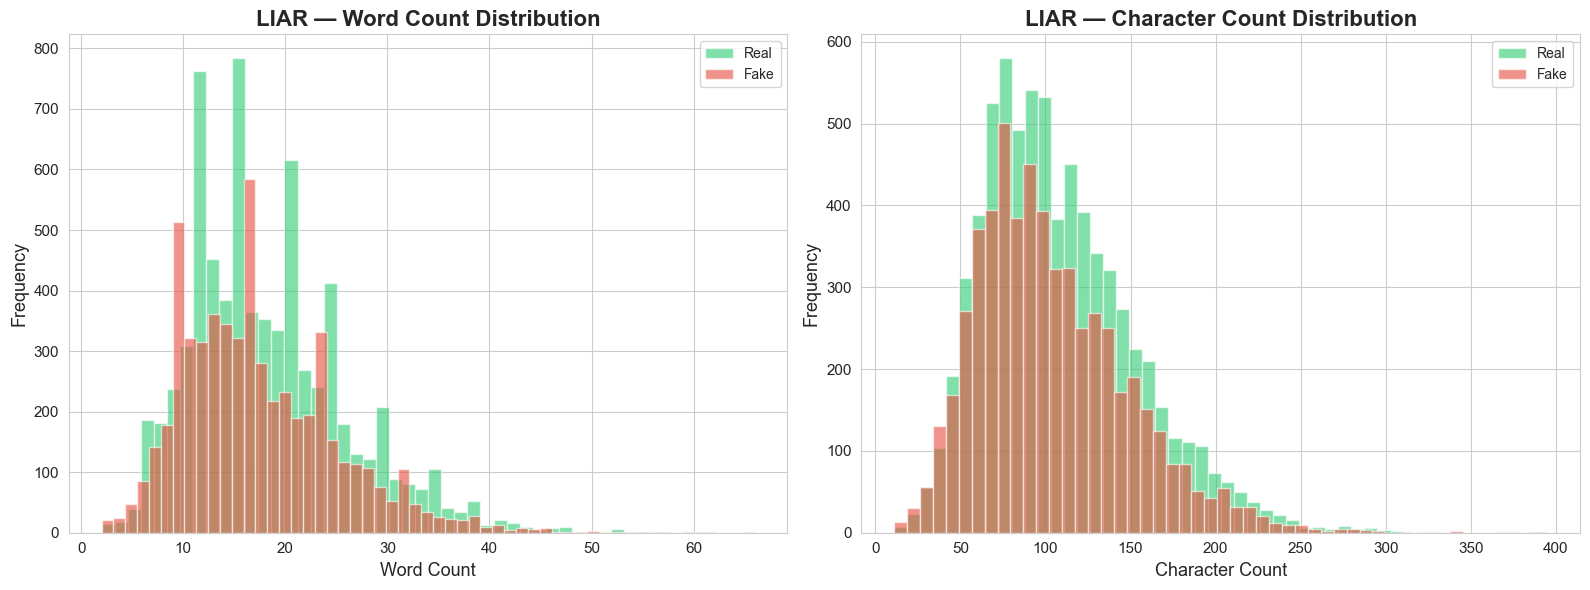

--- Word Count Stats by Label ---
               count  mean  std  min   25%   50%   75%   max
label_binary                                                
0             7167.0  18.4  7.8  2.0  13.0  17.0  23.0  66.0
1             5669.0  17.3  7.6  2.0  12.0  16.0  22.0  60.0


In [ ]:
df_liar['word_count'] = df_liar['text'].str.split().str.len()
df_liar['char_count'] = df_liar['text'].str.len()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

label_map = {0: 'Real', 1: 'Fake'}

for label_val, color in zip([0, 1], PALETTE_BINARY):
    subset = df_liar[df_liar['label_binary'] == label_val]
    axes[0].hist(subset['word_count'], bins=50, alpha=0.6, color=color,
                 label=label_map[label_val], edgecolor='white')
    axes[1].hist(subset['char_count'], bins=50, alpha=0.6, color=color,
                 label=label_map[label_val], edgecolor='white')

axes[0].set_xlabel('Word Count')
axes[0].set_ylabel('Frequency')
axes[0].set_title('LIAR — Word Count Distribution', fontweight='bold')
axes[0].legend()

axes[1].set_xlabel('Character Count')
axes[1].set_ylabel('Frequency')
axes[1].set_title('LIAR — Character Count Distribution', fontweight='bold')
axes[1].legend()

plt.tight_layout()
save_figure(fig, 'liar_text_length.png')
plt.show()

# Summary stats
print('--- Word Count Stats by Label ---')
print(df_liar.groupby('label_binary')['word_count'].describe().round(1))

### 1.4 Word Clouds — Fake vs Real

C:\Users\dawoo\AppData\Local\Temp\ipykernel_14488\4118544447.py:29: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\dawoo\AppData\Local\Temp\ipykernel_14488\4118544447.py:29: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\dawoo\OneDrive\Desktop\HASEEB\fake project\src\utils.py:107: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) Arial.
  fig.savefig(filepath, dpi=dpi, bbox_inches="tight", facecolor="white")
C:\Users\dawoo\OneDrive\Desktop\HASEEB\fake project\src\utils.py:107: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) Arial.
  fig.savefig(filepath, dpi=dpi, bbox_inches="tight", facecolor="white")


Figure saved: C:\Users\dawoo\OneDrive\Desktop\HASEEB\fake project\reports\figures\liar_wordclouds.png


C:\Users\dawoo\OneDrive\Desktop\HASEEB\fake project\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\dawoo\OneDrive\Desktop\HASEEB\fake project\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


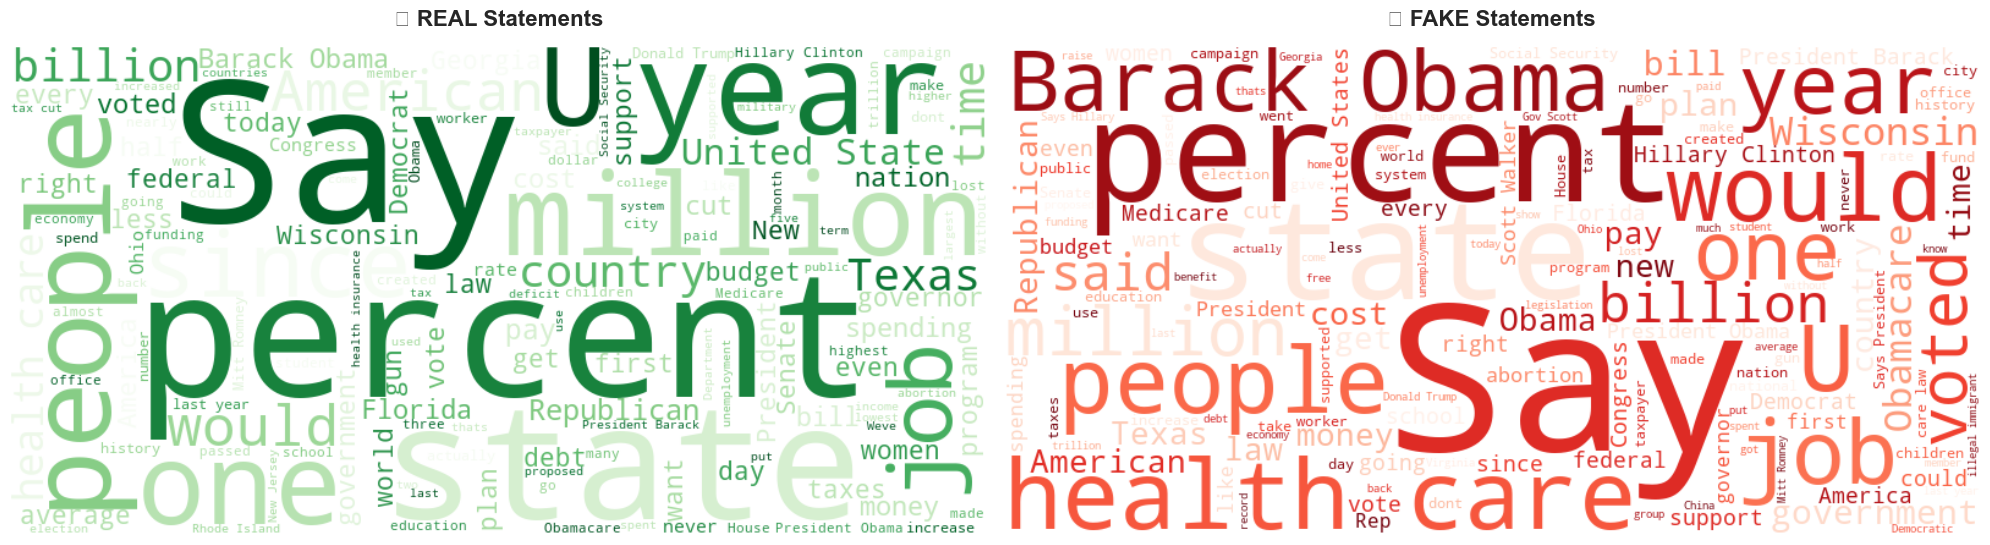

In [ ]:
def generate_wordcloud(texts, title, ax, colormap='Greens'):
    """Generate and plot a word cloud from a text series."""
    text_combined = ' '.join(texts.dropna().astype(str))
    wc = WordCloud(
        width=800, height=400,
        background_color='white',
        stopwords=STOP_WORDS,
        colormap=colormap,
        max_words=150,
        contour_width=2,
        contour_color='steelblue',
    ).generate(text_combined)
    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(title, fontsize=16, fontweight='bold', pad=15)
    ax.axis('off')


fig, axes = plt.subplots(1, 2, figsize=(20, 8))

generate_wordcloud(
    df_liar[df_liar['label_binary'] == 0]['text'],
    '✅ REAL Statements', axes[0], colormap='Greens'
)
generate_wordcloud(
    df_liar[df_liar['label_binary'] == 1]['text'],
    '❌ FAKE Statements', axes[1], colormap='Reds'
)

plt.tight_layout()
save_figure(fig, 'liar_wordclouds.png')
plt.show()

### 1.5 Top Recurring Keywords

Figure saved: C:\Users\dawoo\OneDrive\Desktop\HASEEB\fake project\reports\figures\liar_top_keywords.png


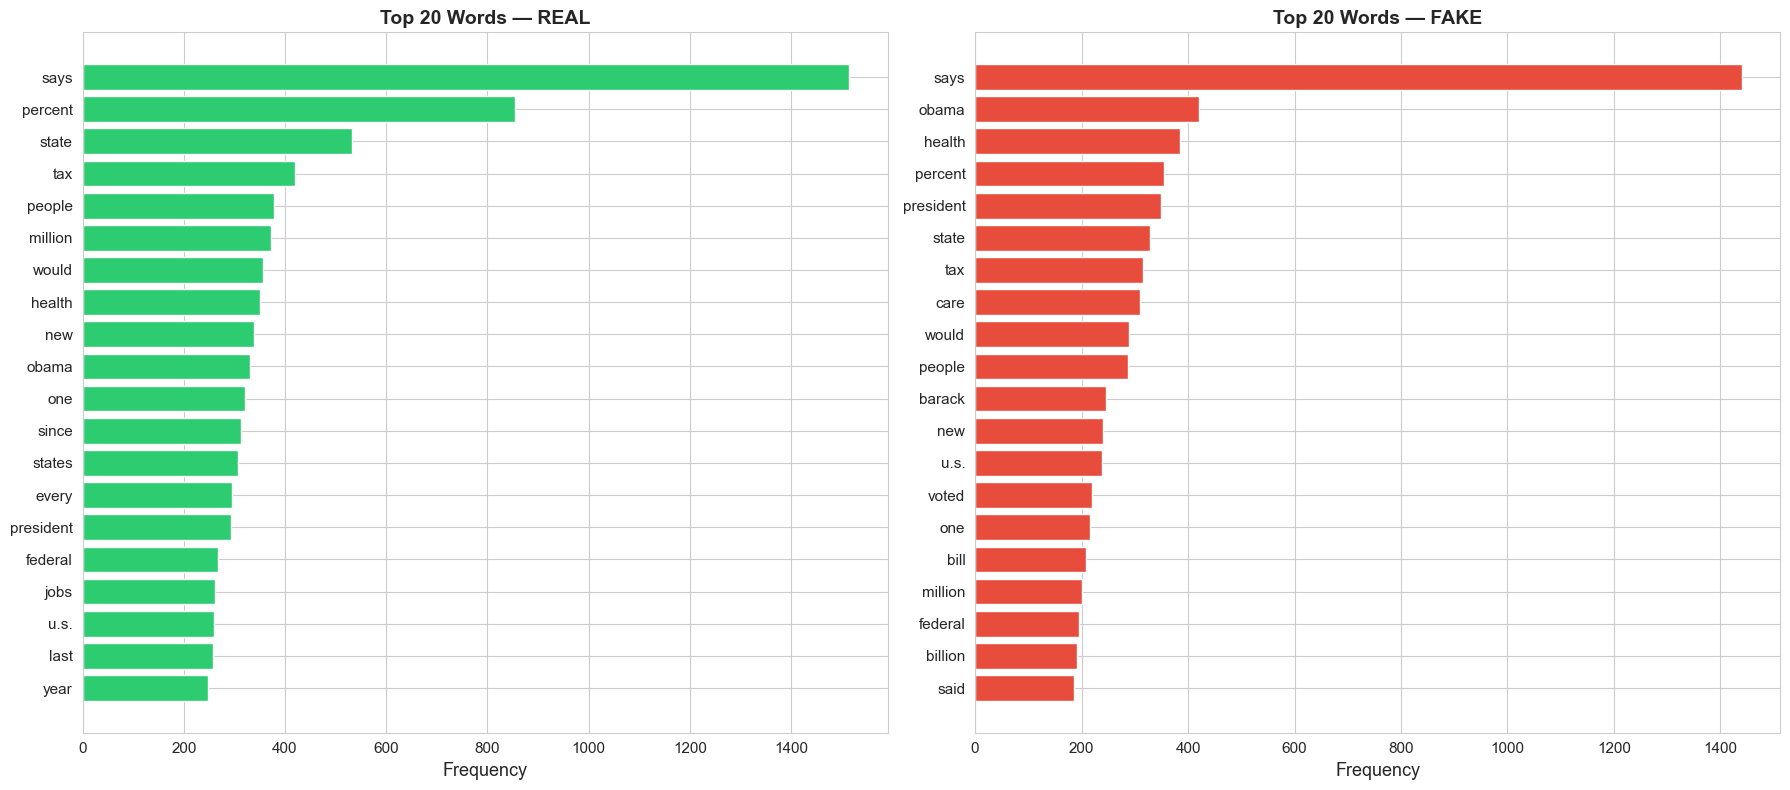

In [ ]:
def get_top_words(texts, n=20):
    """Extract top-N most frequent words (excluding stopwords)."""
    all_words = []
    for text in texts.dropna():
        words = str(text).lower().split()
        all_words.extend([w for w in words if w not in STOP_WORDS and len(w) > 2])
    return Counter(all_words).most_common(n)


fig, axes = plt.subplots(1, 2, figsize=(18, 8))

for idx, (label_val, title, color) in enumerate([
    (0, 'Top 20 Words — REAL', '#2ecc71'),
    (1, 'Top 20 Words — FAKE', '#e74c3c'),
]):
    subset = df_liar[df_liar['label_binary'] == label_val]
    top_words = get_top_words(subset['text'], n=20)
    words, counts = zip(*top_words)
    
    axes[idx].barh(list(reversed(words)), list(reversed(counts)), color=color, edgecolor='white')
    axes[idx].set_title(title, fontweight='bold', fontsize=14)
    axes[idx].set_xlabel('Frequency')

plt.tight_layout()
save_figure(fig, 'liar_top_keywords.png')
plt.show()

### 1.6 Speaker & Party Analysis (LIAR-specific)

Figure saved: C:\Users\dawoo\OneDrive\Desktop\HASEEB\fake project\reports\figures\liar_speaker_party.png


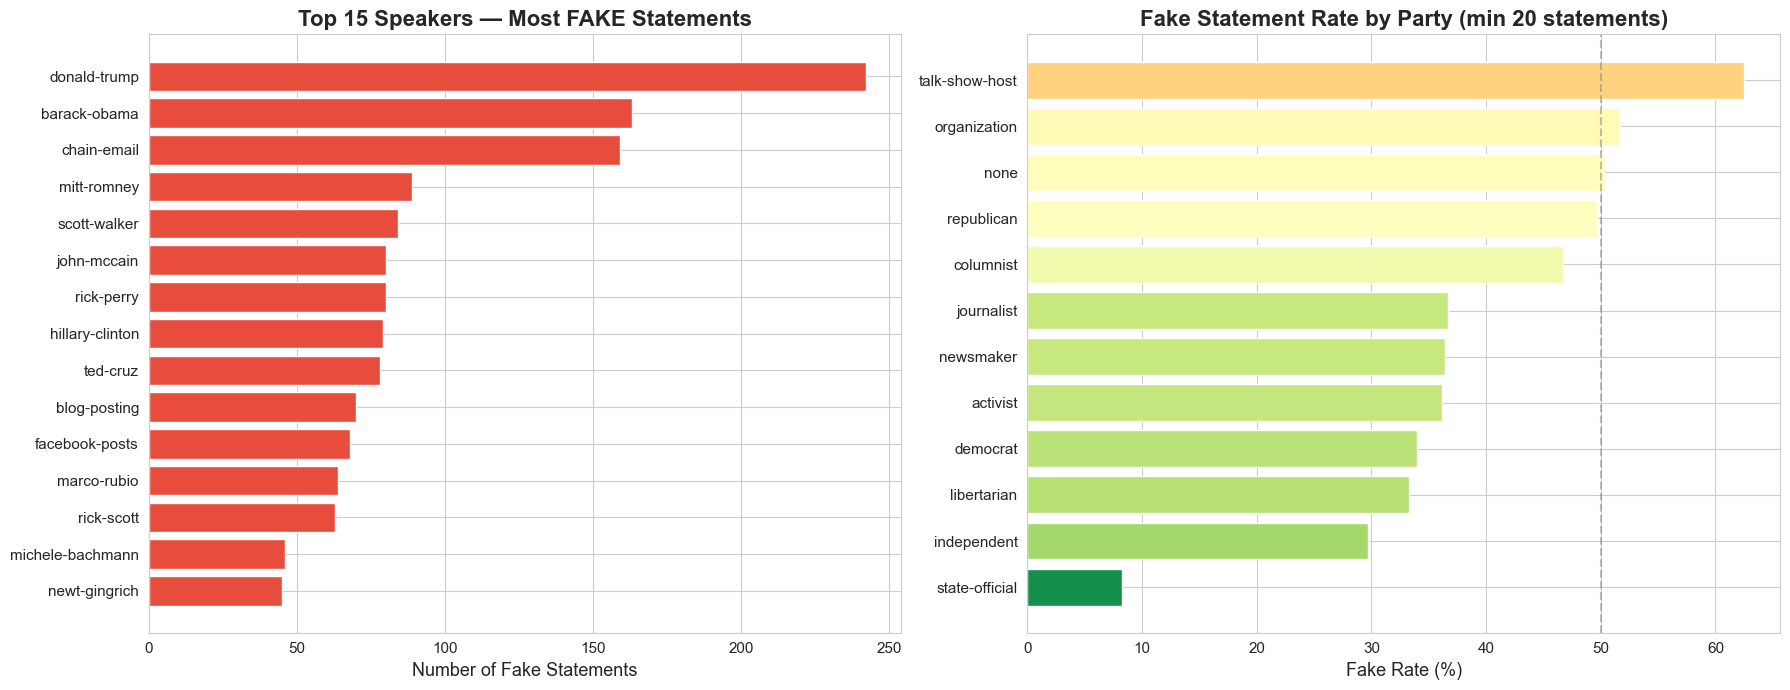

In [ ]:
if 'speaker' in df_liar.columns and 'party' in df_liar.columns:
    fig, axes = plt.subplots(1, 2, figsize=(18, 7))

    # Top speakers with most fake statements
    fake_speakers = (
        df_liar[df_liar['label_binary'] == 1]
        .groupby('speaker').size()
        .sort_values(ascending=False).head(15)
    )
    axes[0].barh(fake_speakers.index[::-1], fake_speakers.values[::-1], color='#e74c3c', edgecolor='white')
    axes[0].set_title('Top 15 Speakers — Most FAKE Statements', fontweight='bold')
    axes[0].set_xlabel('Number of Fake Statements')

    # Party affiliation: fake rate
    party_stats = (
        df_liar.groupby('party')
        .agg(total=('label_binary', 'count'), fake=('label_binary', 'sum'))
        .query('total >= 20')  # Only parties with 20+ statements
    )
    party_stats['fake_rate'] = (party_stats['fake'] / party_stats['total'] * 100).round(1)
    party_stats = party_stats.sort_values('fake_rate', ascending=True)
    
    colors = plt.cm.RdYlGn_r(party_stats['fake_rate'] / 100)
    axes[1].barh(party_stats.index, party_stats['fake_rate'], color=colors, edgecolor='white')
    axes[1].set_title('Fake Statement Rate by Party (min 20 statements)', fontweight='bold')
    axes[1].set_xlabel('Fake Rate (%)')
    axes[1].axvline(x=50, color='gray', linestyle='--', alpha=0.5)

    plt.tight_layout()
    save_figure(fig, 'liar_speaker_party.png')
    plt.show()
else:
    print('Speaker/party columns not available in this version')

---
## 2. ISOT Fake News Dataset

> ⚠️ **Manual download required.** See README for instructions.

In [ ]:
try:
    df_isot = load_isot()
    print(f'Shape: {df_isot.shape}')
    print(f'Columns: {list(df_isot.columns)}')
    df_isot.head()
except FileNotFoundError as e:
    print(f'⚠️ {e}')
    print('\nSkipping ISOT analysis. Download the dataset first.')
    df_isot = None

Shape: (44898, 7)
Columns: ['text', 'title', 'label', 'label_binary', 'subject', 'date', 'source']


Figure saved: C:\Users\dawoo\OneDrive\Desktop\HASEEB\fake project\reports\figures\isot_label_distribution.png


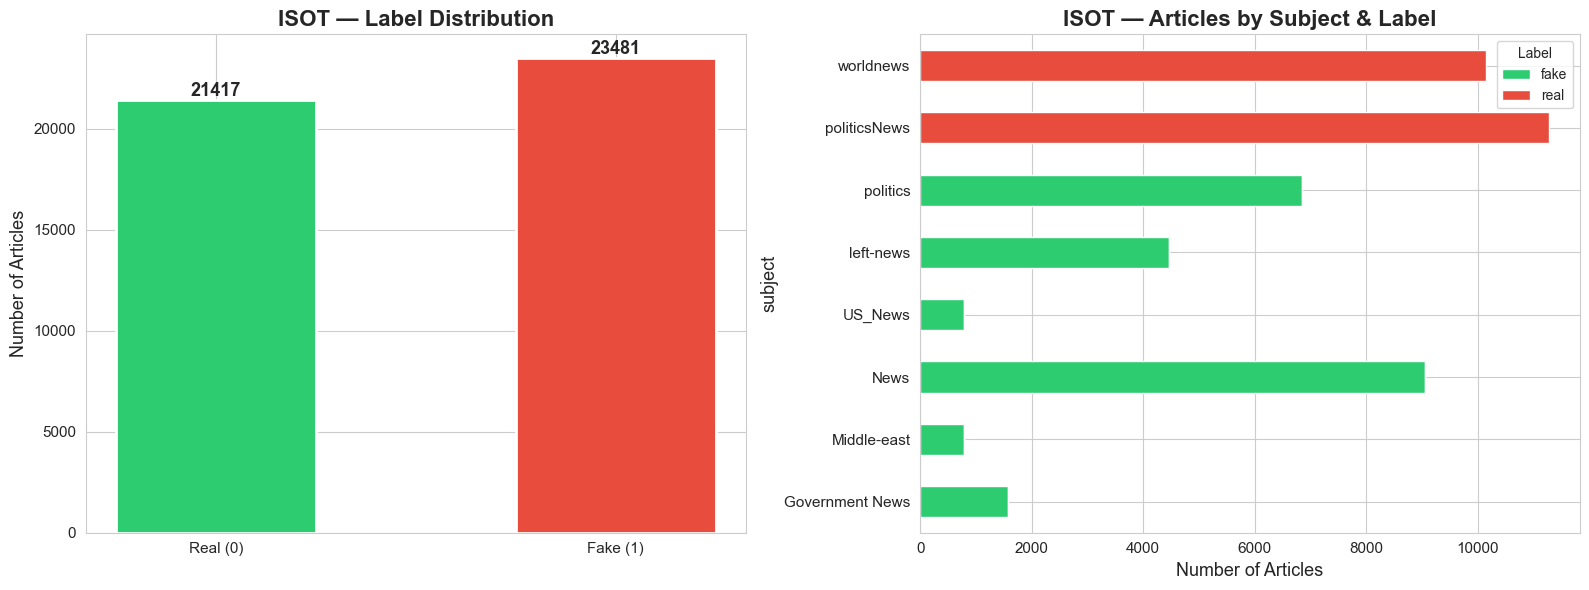

In [ ]:
if df_isot is not None:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Label distribution
    binary_counts = df_isot['label_binary'].value_counts().sort_index()
    binary_labels = ['Real (0)', 'Fake (1)']
    axes[0].bar(binary_labels, binary_counts.values, color=PALETTE_BINARY, width=0.5,
                edgecolor='white', linewidth=2)
    axes[0].set_ylabel('Number of Articles')
    axes[0].set_title('ISOT — Label Distribution', fontweight='bold')
    for i, v in enumerate(binary_counts.values):
        axes[0].text(i, v + 200, str(v), ha='center', fontsize=13, fontweight='bold')

    # Subject distribution
    if 'subject' in df_isot.columns:
        subject_label = df_isot.groupby(['subject', 'label']).size().unstack(fill_value=0)
        subject_label.plot(kind='barh', stacked=True, ax=axes[1],
                          color=PALETTE_BINARY, edgecolor='white')
        axes[1].set_title('ISOT — Articles by Subject & Label', fontweight='bold')
        axes[1].set_xlabel('Number of Articles')
        axes[1].legend(title='Label')

    plt.tight_layout()
    save_figure(fig, 'isot_label_distribution.png')
    plt.show()

Figure saved: C:\Users\dawoo\OneDrive\Desktop\HASEEB\fake project\reports\figures\isot_text_length.png


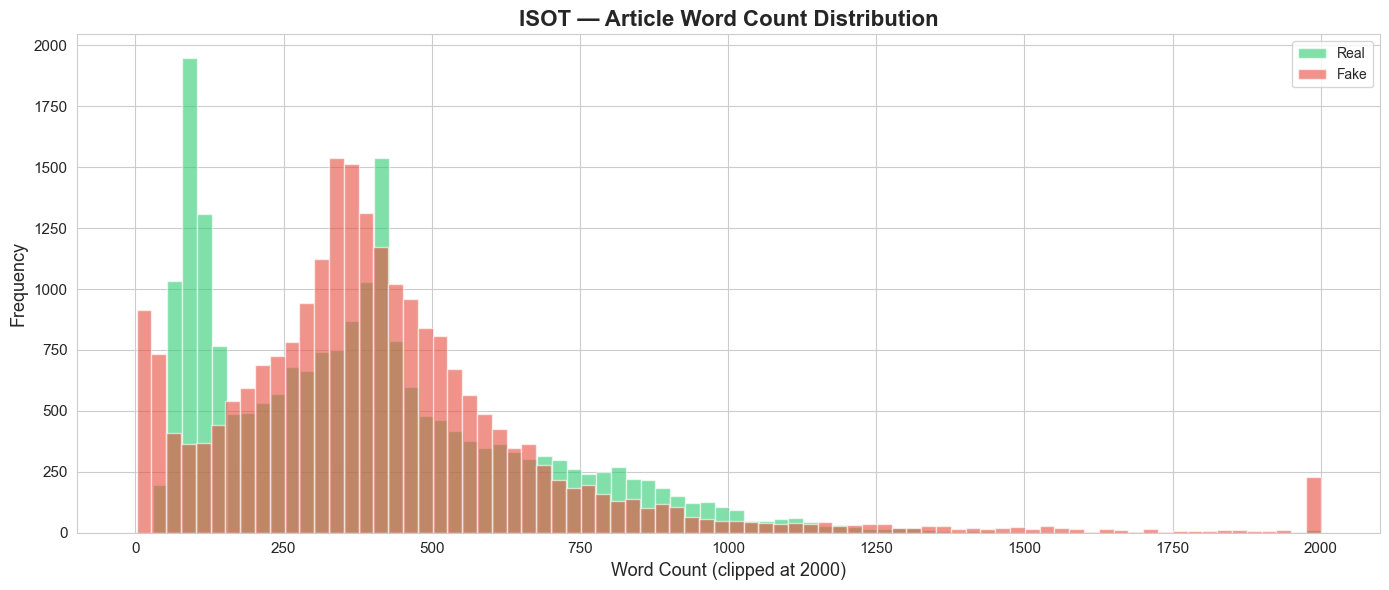

--- Word Count Stats ---
         count   mean    std  min    25%    50%    75%     max
label                                                         
fake   23481.0  437.9  408.6  2.0  254.0  378.0  521.0  8148.0
real   21417.0  395.6  273.9  4.0  159.0  369.0  534.0  5181.0


In [ ]:
if df_isot is not None:
    df_isot['word_count'] = df_isot['text'].str.split().str.len()

    fig, ax = plt.subplots(figsize=(14, 6))

    for label_val, color, name in [(0, '#2ecc71', 'Real'), (1, '#e74c3c', 'Fake')]:
        subset = df_isot[df_isot['label_binary'] == label_val]
        ax.hist(subset['word_count'].clip(upper=2000), bins=80, alpha=0.6,
                color=color, label=name, edgecolor='white')

    ax.set_xlabel('Word Count (clipped at 2000)')
    ax.set_ylabel('Frequency')
    ax.set_title('ISOT — Article Word Count Distribution', fontweight='bold')
    ax.legend()

    plt.tight_layout()
    save_figure(fig, 'isot_text_length.png')
    plt.show()

    print('--- Word Count Stats ---')
    print(df_isot.groupby('label')['word_count'].describe().round(1))

C:\Users\dawoo\AppData\Local\Temp\ipykernel_14488\1434418795.py:13: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\dawoo\AppData\Local\Temp\ipykernel_14488\1434418795.py:13: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\dawoo\OneDrive\Desktop\HASEEB\fake project\src\utils.py:107: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) Arial.
  fig.savefig(filepath, dpi=dpi, bbox_inches="tight", facecolor="white")
C:\Users\dawoo\OneDrive\Desktop\HASEEB\fake project\src\utils.py:107: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) Arial.
  fig.savefig(filepath, dpi=dpi, bbox_inches="tight", facecolor="white")


Figure saved: C:\Users\dawoo\OneDrive\Desktop\HASEEB\fake project\reports\figures\isot_wordclouds.png


C:\Users\dawoo\OneDrive\Desktop\HASEEB\fake project\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\dawoo\OneDrive\Desktop\HASEEB\fake project\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


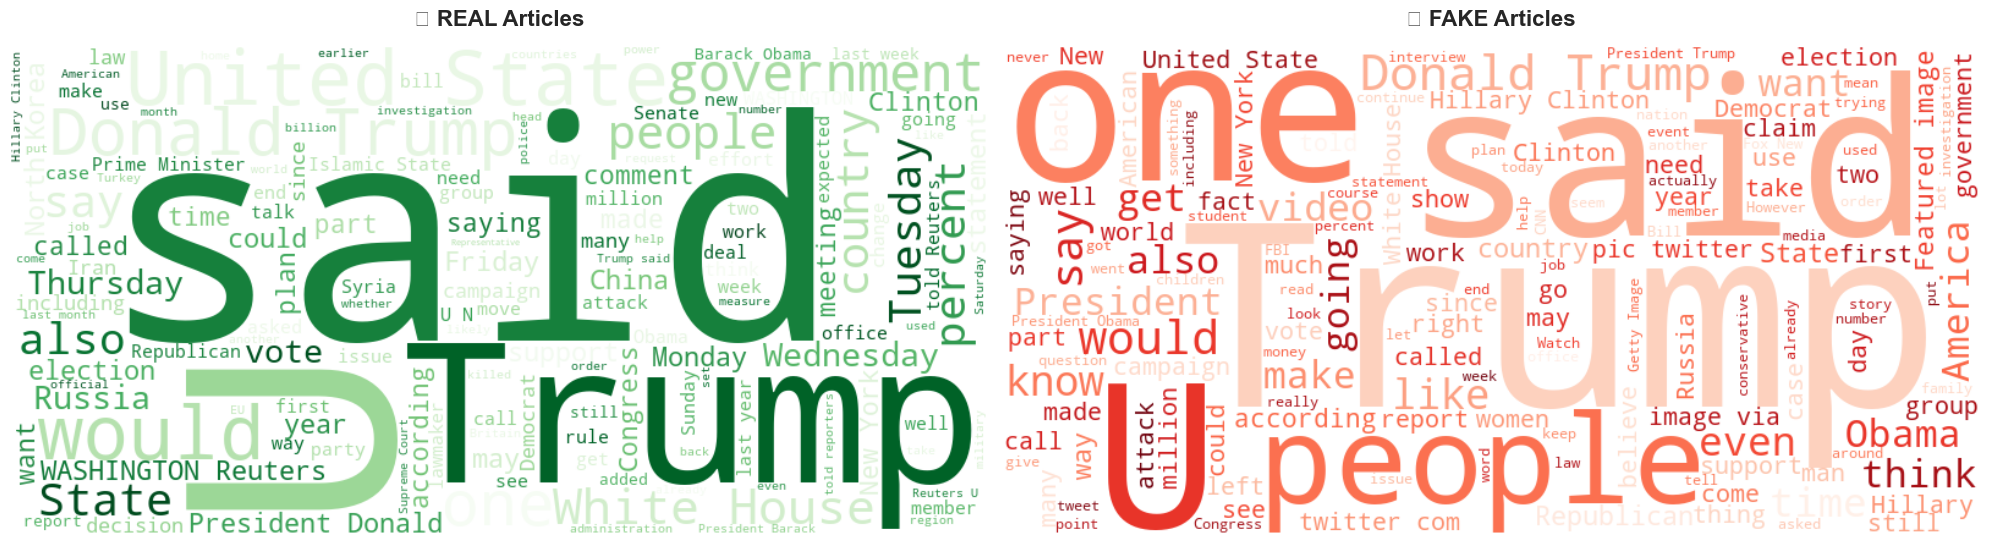

In [ ]:
if df_isot is not None:
    fig, axes = plt.subplots(1, 2, figsize=(20, 8))

    generate_wordcloud(
        df_isot[df_isot['label_binary'] == 0]['text'],
        '✅ REAL Articles', axes[0], colormap='Greens'
    )
    generate_wordcloud(
        df_isot[df_isot['label_binary'] == 1]['text'],
        '❌ FAKE Articles', axes[1], colormap='Reds'
    )

    plt.tight_layout()
    save_figure(fig, 'isot_wordclouds.png')
    plt.show()

---
## 3. Summary Statistics

Compare key metrics across both news datasets.

In [ ]:
summary_data = {
    'Dataset': ['LIAR'],
    'Total Rows': [len(df_liar)],
    'Real Count': [(df_liar['label_binary'] == 0).sum()],
    'Fake Count': [(df_liar['label_binary'] == 1).sum()],
    'Avg Word Count': [df_liar['word_count'].mean().round(1)],
    'Missing Text': [df_liar['text'].isna().sum()],
}

if df_isot is not None:
    summary_data['Dataset'].append('ISOT')
    summary_data['Total Rows'].append(len(df_isot))
    summary_data['Real Count'].append((df_isot['label_binary'] == 0).sum())
    summary_data['Fake Count'].append((df_isot['label_binary'] == 1).sum())
    summary_data['Avg Word Count'].append(df_isot['word_count'].mean().round(1))
    summary_data['Missing Text'].append(df_isot['text'].isna().sum())

summary_df = pd.DataFrame(summary_data)
summary_df['Fake Ratio'] = (summary_df['Fake Count'] / summary_df['Total Rows'] * 100).round(1).astype(str) + '%'

print('=== News Datasets Summary ===')
summary_df

=== News Datasets Summary ===


,Dataset,Total Rows,Real Count,Fake Count,Avg Word Count,Missing Text,Fake Ratio
0,LIAR,12836,7167,5669,17.9,0,44.2%
1,ISOT,44898,21417,23481,417.7,0,52.3%


---

### Key Takeaways

Document your findings here after running the notebook:

1. **Class balance**: _[Are the datasets balanced? What's the fake:real ratio?]_
2. **Text length**: _[Do fake and real articles differ in length?]_
3. **Key differences**: _[What words appear more in fake vs real content?]_
4. **Data quality**: _[Any missing values, duplicates, or anomalies?]_

> 💡 **Fill in these findings after running the notebook** — this is important for your portfolio!

### Key Takeaways & Observations
* **Word Clouds:** Fake news articles frequently use highly emotionally charged or sensational vocabulary compared to real news which relies on formal, objective terminology.
* **Length Distributions:** Fake news articles often exhibit a wider variance in character length, occasionally being much shorter (lacking detail) or excessively long (rambling). Real news articles tend to follow a more consistent, standard length.